In [1]:
import openeo
from fusets.openeo import load_whittakker_udf
from fusets.openeo import whittaker_udf

connection = openeo.connect("openeo.terrascope.be").authenticate_oidc()

Authenticated using refresh token.


## Load Terrascope S2 BIOPAR FAPAR and LAI at 20m resolution

Required:
- Input data: Terrascope S2 BIOPAR LAI and FAPAR at 20m
- Spatial extent: NUTS3 region ‘Tongeren’, gpkg shared in mail thread
- Time window:
    - Season 1: August/2024 – Dec/2025 (the focus is the season Oct/2024 – Oct/2025, but it is good to have some data before and after to test the smoothing/gap filling algorithm)
    - Season 2: August/2025 – now (the focus is the season Oct/2025 – NRT)

In [2]:
import geopandas as gpd

Tongeren_polygon = gpd.read_file("NUTS3_Tongeren.gpkg")
print(f"type: {type(Tongeren_polygon)} with crs: {Tongeren_polygon.crs}")
# load to 4326
Tongeren_polygon = Tongeren_polygon.to_crs("EPSG:4326")
print(f"type: {type(Tongeren_polygon)} with crs: {Tongeren_polygon.crs}")


type: <class 'geopandas.geodataframe.GeoDataFrame'> with crs: EPSG:3035
type: <class 'geopandas.geodataframe.GeoDataFrame'> with crs: EPSG:4326


In [3]:
# feature collection from geopandas dataframe
import json
aoi = json.loads(Tongeren_polygon.to_json())

In [4]:
# Time window:
# - Season 1: August/2024 – Dec/2025 (the focus is the season Oct/2024 – Oct/2025, but it is good to have some data before and after to test the smoothing/gap filling algorithm)
# - Season 2: August/2025 – now (the focus is the season Oct/2025 – NRT)
season1 = ["2024-08-01", "2025-12-31"]
season2 = ["2025-08-01", "2026-08-31"]
test_date = ["2025-10-01", "2025-10-31"]

In [5]:
s2_fapar = connection.load_stac(
    url = "https://stac.terrascope.be/collections/terrascope-s2-fapar-v2",
    spatial_extent = aoi,
    temporal_extent = test_date,
    bands = ["FAPAR"],
    properties = {"gsd":lambda x: x==20}
)
scale = 0.005
offset = 0

s2_fapar_scaled = s2_fapar.apply(lambda x: x * scale + offset)

In [6]:
# lai
url = "https://stac.terrascope.be/collections/terrascope-s2-lai-v2"

## Filter FAPAR and LAI based on a parcel delineation map

More data on the gpkg in ticket and mail.

In [7]:
# load field from parcel delination
fields = gpd.read_file("AGRIPRC2026_Tongeren_selection.gpkg")
fields = fields.to_crs("EPSG:4326")
subset_fields = fields[:10]  # select first 5 fields for testing

In [12]:
# subset_fields

In [8]:
delineated_map = s2_fapar.filter_spatial(json.loads(subset_fields.to_json()))

In [10]:
# import os
# OUTPUT_PATCH_DIR = "delination_map_patches"
# os.makedirs(OUTPUT_PATCH_DIR, exist_ok=True)

# # Export one GeoTIFF per training polygon.
# job = delination_map.create_job(
#     out_format="GTiff",
#     title="delineated fapar",
#     sample_by_feature=True,
#     feature_id_property="AGPAKEY",
# )
# job.start_and_wait()
# job.get_results().download_files(OUTPUT_PATCH_DIR)

I downloaded individual data for each parcels. Is it required as this or a full image with filtered values for the parcels?

## Run a Whittaker smoother for 2 scenarios:

- Pixel-based
- On Average FAPAR / LAI per parcel

The whittaker smoother requires a lambda parameter. Will need to follow up if it is whittaker service or a local implementation.

#### 1. pixel-based smoothening

In [9]:
# apply Whittaker smoothing UDF along the temporal dimension
smoothed = delineated_map.apply_dimension(
    process=openeo.UDF.from_file("udf_whittaker.py"),
    dimension="t",
    context={"lmbda": 15, "d": 2},
)

In [ ]:
# Quality layers: count valid observations along time before and after smoothing.
# count_time() counts non-nodata values and preserves the spatial dimensions.
valid_before = delineated_map.count_time().rename_labels("bands", ["valid_before"])
valid_after = smoothed.count_time().rename_labels("bands", ["valid_after"])

# Replace nodata with zero so the denominator includes every temporal label.
from openeo.processes import if_
total_timesteps = (
    delineated_map.apply(lambda x: if_(x.is_nodata(), 0, 1))
    .count_time()
    .rename_labels("bands", ["total_timesteps"])
)

valid_percentage_before = (valid_before / total_timesteps * 100).rename_labels(
    "bands", ["valid_percentage_before"]
)
valid_percentage_after = (valid_after / total_timesteps * 100).rename_labels(
    "bands", ["valid_percentage_after"]
)

# One output cube with two percentage bands. Save this separately from the
# smoothed FAPAR cube, or export both bands together as one quality file.
quality_layers = valid_percentage_before.merge_cubes(valid_percentage_after)

quality_job = quality_layers.execute_batch(
    title="FAPAR valid pixel percentage before and after Whittaker",
    outputfile="fapar_quality_before_after.tif",
)


In [11]:
# aggregate deaked after whittaker
smoothed_dekad = smoothed.aggregate_temporal_period(reducer="mean", period="dekad")
deked_job = smoothed_dekad.create_job(
    title="smoothed dekad aggregation",
    sample_by_feature=True,
    feature_id_property="AGPAKEY"
)
deked_job.start_and_wait()


0:00:00 Job 'j-26090408011246bcbed74188e24a4bd1': send 'start'
0:00:14 Job 'j-26090408011246bcbed74188e24a4bd1': created (progress 0%)
0:00:19 Job 'j-26090408011246bcbed74188e24a4bd1': queued (progress 0%)
0:00:26 Job 'j-26090408011246bcbed74188e24a4bd1': queued (progress 0%)
0:00:34 Job 'j-26090408011246bcbed74188e24a4bd1': queued (progress 0%)
0:00:44 Job 'j-26090408011246bcbed74188e24a4bd1': running (progress 4.9%)
0:00:57 Job 'j-26090408011246bcbed74188e24a4bd1': running (progress 6.8%)
0:01:12 Job 'j-26090408011246bcbed74188e24a4bd1': running (progress 9.0%)
0:01:31 Job 'j-26090408011246bcbed74188e24a4bd1': running (progress 11.6%)
0:01:55 Job 'j-26090408011246bcbed74188e24a4bd1': running (progress 14.6%)
0:02:26 Job 'j-26090408011246bcbed74188e24a4bd1': running (progress 18.1%)
0:03:03 Job 'j-26090408011246bcbed74188e24a4bd1': running (progress 22.1%)
0:03:50 Job 'j-26090408011246bcbed74188e24a4bd1': finished (progress 100%)


<BatchJob job_id='j-26090408011246bcbed74188e24a4bd1'>

In [17]:
# pixel_based_job = smoothed.create_job(
#     title="smoothed on delineated map", 
#     )
# pixel_based_job.start_and_wait()

In [18]:
# results = pixel_based_job.get_results()
# results.download_files("pixel_based/")

#### 2. Average FAPAR per parcel

In [11]:
fapar_timeseries = s2_fapar.aggregate_spatial(json.loads(subset_fields.to_json()), reducer="mean")

In [12]:
fapar_timeseries_temporal = fapar_timeseries.process(
    process_id="aggregate_temporal_period",
    arguments={
        "data": fapar_timeseries,
        "period": "dekad",
        "reducer": {
            "process_graph": {
                "mean1": {
                    "process_id": "mean",
                    "arguments": {
                        "data": {"from_parameter": "data"}
                    },
                    "result": True,
                }
            }
        },
    },
)

In [ ]:
# fapar_timeseries_temporal = fapar_timeseries.aggregate_temporal_period(reducer="mean", period="dekad")
# s2_fapar_temporal = s2_fapar.process(process_id="aggregate_temporal_period", data=s2_fapar, arguments={"reducer": "mean", "period": "dekad"})

In [19]:
# fapar_timeseries_temporal.execute_batch()

In [14]:
# On Average FAPAR / LAI per parcel
fapar_timeseries = s2_fapar.aggregate_spatial(json.loads(subset_fields.to_json()), reducer="mean")
fapar_timeseries_smoothened = fapar_timeseries.run_udf(
        udf=openeo.UDF.from_file("udf_whittaker_ts.py"),
        runtime="Python",
        context={"lmbda": 15, "d": 2},
)

In [15]:
timeseries_job = fapar_timeseries.execute_batch(
    title="fapar_timeseries for Tongeren",
    outputfile="fapar_timeseries_avg_b4smoothening_1yr.json")

0:00:00 Job 'cdse-j-2608310732044134b83e404e9f860322': send 'start'
0:00:05 Job 'cdse-j-2608310732044134b83e404e9f860322': created (progress 0%)
0:00:10 Job 'cdse-j-2608310732044134b83e404e9f860322': queued (progress 0%)
0:00:17 Job 'cdse-j-2608310732044134b83e404e9f860322': queued (progress 0%)
0:00:25 Job 'cdse-j-2608310732044134b83e404e9f860322': queued (progress 0%)
0:00:35 Job 'cdse-j-2608310732044134b83e404e9f860322': queued (progress 0%)
0:00:47 Job 'cdse-j-2608310732044134b83e404e9f860322': queued (progress 0%)
0:01:03 Job 'cdse-j-2608310732044134b83e404e9f860322': running (progress N/A)
0:01:22 Job 'cdse-j-2608310732044134b83e404e9f860322': running (progress N/A)
0:01:46 Job 'cdse-j-2608310732044134b83e404e9f860322': running (progress N/A)
0:02:16 Job 'cdse-j-2608310732044134b83e404e9f860322': running (progress N/A)
0:02:54 Job 'cdse-j-2608310732044134b83e404e9f860322': running (progress N/A)
0:03:41 Job 'cdse-j-2608310732044134b83e404e9f860322': running (progress N/A)
0:04:40

In [20]:
# smoothed_timeseries_job = fapar_timeseries_smoothened.execute_batch(
#     title="fapar_timeseries_smoothened for Tongeren",
#     outputfile="fapar_timeseries_avg_after_smoothening_1yr.json")

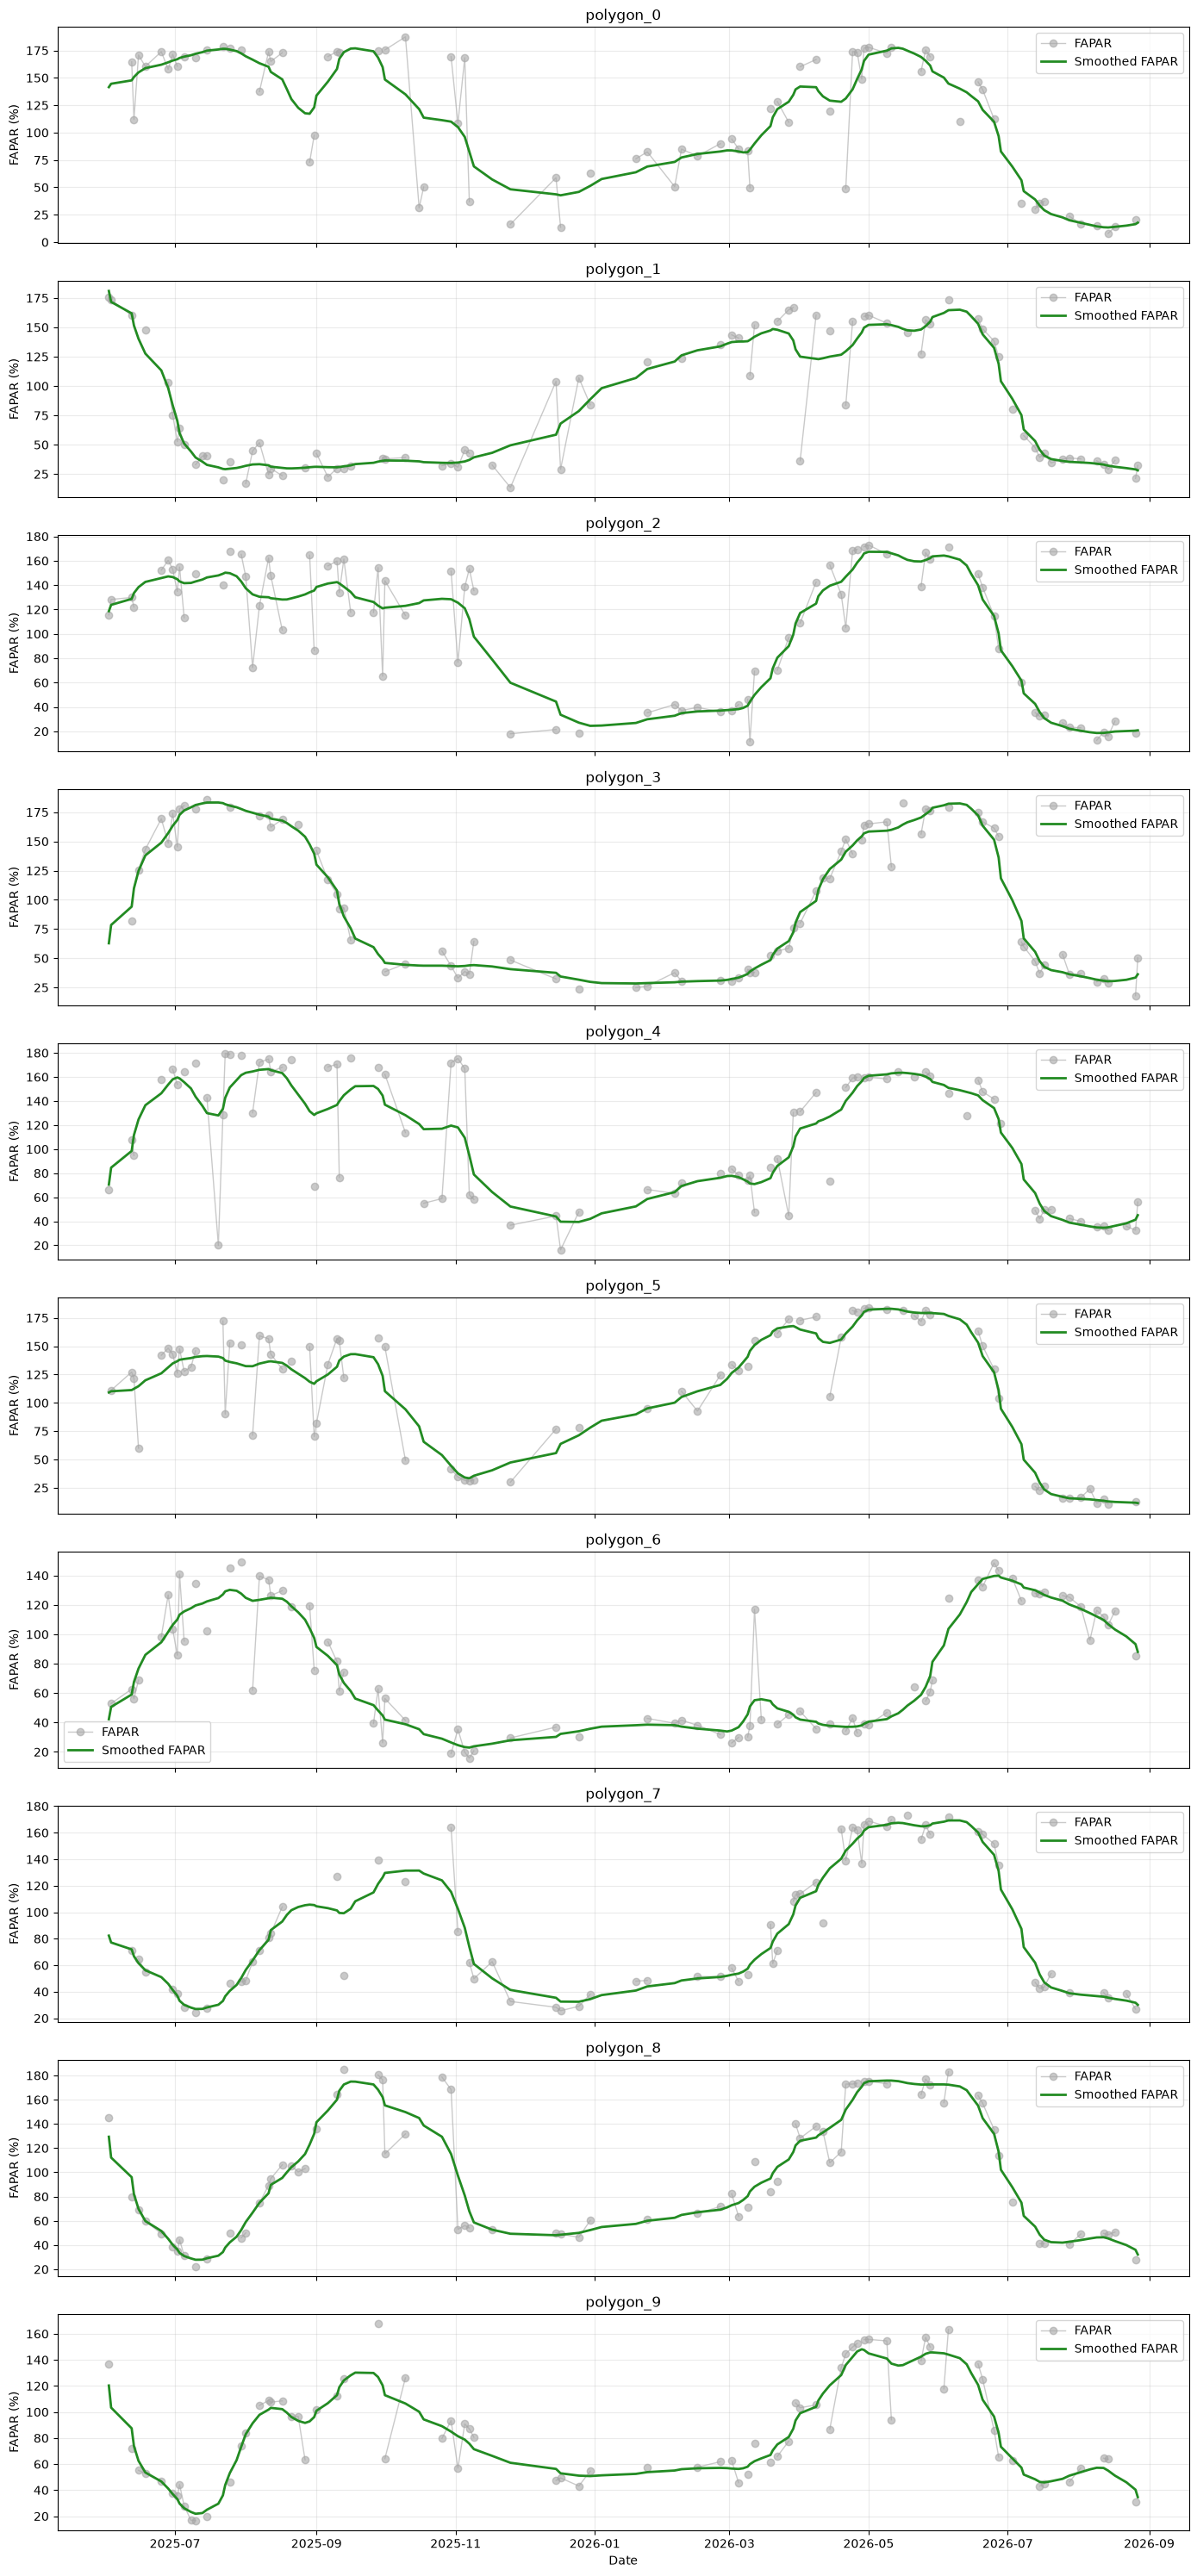

In [22]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# raw output: {date: [[value_polygon_0], [value_polygon_1], ...]}
with open("fapar_timeseries_avg_b4smoothening_1yr.json") as f:
    raw_data = json.load(f)

n_polygons = len(next(iter(raw_data.values())))
raw_fapar = pd.DataFrame(
    {f"polygon_{i}": {date: values[i][0] for date, values in raw_data.items()} for i in range(n_polygons)}
)
raw_fapar.index = pd.to_datetime(raw_fapar.index)
raw_fapar = raw_fapar.sort_index()

# smoothed output: {"variable_0_polygon_N": {date: value}}
with open("fapar_timeseries_avg_after_smoothening_1yr.json") as f:
    smoothed_data = json.load(f)

smoothed_fapar = pd.DataFrame(
    {key.replace("variable_0_", ""): pd.Series(values) for key, values in smoothed_data.items()}
)
smoothed_fapar.index = pd.to_datetime(smoothed_fapar.index)
smoothed_fapar = smoothed_fapar.sort_index()

fig, axes = plt.subplots(n_polygons, 1, figsize=(14, 3 * n_polygons), sharex=True)
for i, ax in enumerate(axes):
    col = f"polygon_{i}"
    ax.plot(raw_fapar.index, raw_fapar[col], color="0.65", marker="o", linewidth=1, alpha=0.6, label="FAPAR")
    if col in smoothed_fapar.columns:
        ax.plot(smoothed_fapar.index, smoothed_fapar[col], color="forestgreen", linewidth=2, label="Smoothed FAPAR")
    ax.set_title(col)
    ax.set_ylabel("FAPAR (%)")
    ax.grid(True, alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.show()